#**Final Report**





## Carga y Preprocesamiento de Datos

In [1]:
import pandas as pd
import numpy as np
import datetime
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Instalar nltk
!pip install --quiet nltk

# Importar y descargar recursos necesarios
import nltk
nltk.download('vader_lexicon')  # Para análisis de sentimientos
nltk.download('punkt')          # Para tokenización
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.nn.functional import softmax
from tqdm import tqdm


# Cargar el modelo BERT especializado para análisis de sentimientos
from transformers import AutoTokenizer, AutoModelForSequenceClassification

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
dataframe_original = pd.read_csv('/content/balanced_airline_reviews.csv')
dataframe_original.shape

(17150, 34)

# Análisis de sentimientos

**Análisis de Sentimientos con VADER**

El objetivo de esta sección es analizar las opiniones de los pasajeros para entender la percepción general del servicio de la aerolínea. Usamos el modelo VADER (Valence Aware Dictionary and sEntiment Reasoner), una herramienta para el análisis de sentimientos en textos cortos como reseñas.

Cálculo de Polaridad
Cada reseña se evalúa en función de su tono (positivo, negativo o neutral). Esto se logra mediante un puntaje de polaridad compuesto que resume la actitud general del texto y se agrega como una nueva columna en el dataset.

Clasificación de Polaridades
Se dividen las reseñas en tres categorías: Positiva, Neutral y Negativa, con base en el puntaje de polaridad. Esto permite entender la distribución general de las opiniones y su relación con otras métricas como la recomendación del servicio.

En un primer momento, se prueba con pocos datos por temas de procesamiento de la computadora.

In [3]:
small_sample = dataframe_original.sample(n=100, random_state=42)
small_sample['recommended'].value_counts()

,count
recommended,
0,57
1,43


In [4]:
def classify_polarity(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

In [5]:
# Descargar recursos de NLTK necesarios
nltk.download('vader_lexicon')

# Inicializamos el analizador de sentimientos
sid = SentimentIntensityAnalyzer()

# Calcular puntajes de polaridad para cada reseña en la muestra
small_sample['vader_polarity'] = small_sample['customer_review'].apply(lambda x: sid.polarity_scores(str(x))['compound'])

small_sample['vader_sentiment'] = small_sample['vader_polarity'].apply(classify_polarity)
small_sample[['customer_review', 'vader_sentiment']].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,customer_review,vader_sentiment
5762,Los Angeles to Charlotte. Unreliable with a p...,Negative
5620,Providence to Tampa. Flight out of Tampa was ...,Negative
5174,"Honolulu to San Diego August 23, 2018 I was f...",Positive
3692,Houston to Frankfurt. I was a frequent flyer ...,Negative
16742,5/28/15 PVD-ATL-CAE 6/1/15 CAE-ATL-PVD. Flight...,Negative


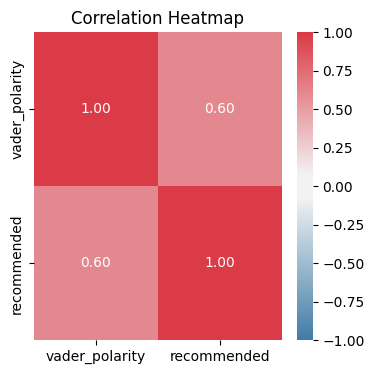

In [6]:
corr_values = small_sample[['vader_polarity','recommended']].dropna(axis=0,how='any').corr()

plt.figure(figsize=(4, 4))
cmap = sns.diverging_palette(240, 10, sep=20, as_cmap=True)
sns.heatmap(corr_values, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

La variable vader_polarity tiene una buena correlacion con la variable recommended, pero considero que este dato podria mejorar.

**Análisis de Sentimientos con BERT**

In [7]:
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")
model = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")

# Definir la función para realizar inferencia
def bert_inference(df_sample):
    model.eval()
    predictions = []

    # Procesar en lotes (ajusta el tamaño según tu hardware)
    for i in tqdm(range(0, len(df_sample), 32), desc="Inferencia de Sentimientos BERT"):
        batch_reviews = df_sample['customer_review'].iloc[i:i+32].tolist()
        tokens = tokenizer(
            batch_reviews,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        # Realizar inferencia
        with torch.no_grad():
            outputs = model(**tokens)
            logits = outputs.logits  # Valores en bruto del modelo
            print("Logits:", logits)  # Ver logits para depuración

            probs = softmax(logits, dim=1)  # Convertir logits a probabilidades
            print("Probabilidades:", probs)  # Ver probabilidades

            batch_predictions = torch.argmax(probs, axis=1).numpy()
            predictions.extend(batch_predictions)

    return predictions

# Ejecutar la inferencia con la muestra pequeña
bert_predictions = bert_inference(small_sample)

# Mapear los resultados a etiquetas de sentimiento
sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
small_sample['bert_sentiment'] = [sentiment_map[pred] for pred in bert_predictions]

small_sample[['customer_review', 'bert_sentiment']]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

Inferencia de Sentimientos BERT:  75%|███████▌  | 3/4 [01:01<00:18, 18.66s/it]

Logits: tensor([[-1.3889, -0.0924,  1.7508],
        [-0.8759,  0.0574,  1.1547],
        [-2.0807, -0.3146,  2.9463],
        [ 2.6866, -0.1437, -2.5520],
        [ 1.9535, -0.0665, -1.9157],
        [ 1.9674,  0.1621, -2.1756],
        [-2.3542, -0.3929,  3.3632],
        [-1.9264, -0.5400,  3.0921],
        [ 2.5021, -0.1978, -2.3637],
        [-2.5852, -0.1575,  3.3062],
        [ 0.5293,  0.1101, -0.6452],
        [-2.4170, -0.2540,  3.3005],
        [ 0.7964,  0.1011, -0.8278],
        [-2.6232, -0.2256,  3.5755],
        [-0.4343, -0.1500,  0.7716],
        [ 0.9280,  0.2504, -1.1743],
        [ 3.2063, -0.5671, -2.6586],
        [ 0.8362,  0.5873, -1.4159],
        [-0.6144,  0.4747,  0.2081],
        [ 2.4039, -0.1305, -2.2312],
        [ 0.8466,  0.4184, -1.3001],
        [-0.2095,  0.2655,  0.0291],
        [-2.6740,  0.1291,  2.9965],
        [-2.9827, -0.0488,  3.5703],
        [ 2.0692,  0.0873, -2.1601],
        [ 2.5188, -0.2123, -2.3395],
        [ 0.6656,  0.2495, -0.

Inferencia de Sentimientos BERT: 100%|██████████| 4/4 [01:03<00:00, 15.87s/it]

Logits: tensor([[ 1.6579,  0.1503, -1.9155],
        [ 2.0037,  0.0777, -2.0801],
        [ 1.2787,  0.4254, -1.7277],
        [-2.3220, -0.1043,  3.0015]])
Probabilidades: tensor([[0.8003, 0.1772, 0.0225],
        [0.8602, 0.1253, 0.0145],
        [0.6777, 0.2887, 0.0335],
        [0.0046, 0.0427, 0.9527]])


,customer_review,bert_sentiment
5762,Los Angeles to Charlotte. Unreliable with a p...,Negative
5620,Providence to Tampa. Flight out of Tampa was ...,Negative
5174,"Honolulu to San Diego August 23, 2018 I was f...",Negative
3692,Houston to Frankfurt. I was a frequent flyer ...,Negative
16742,5/28/15 PVD-ATL-CAE 6/1/15 CAE-ATL-PVD. Flight...,Neutral
...,...,...
4032,Flight 2326 from Lubbock to Atlanta got cancel...,Negative
3366,I feel that Spirit Airlines is in the business...,Negative
59,Terrible experience on my Spirit flight from ...,Negative
5758,First and absolute last time we will ever fly...,Negative


Tabla Comparativa de Categorías:
          Vader Sentiment  Bert Sentiment
Negative               43              59
Neutral                 3               7
Positive               54              34
_________________________________________________________________________________________



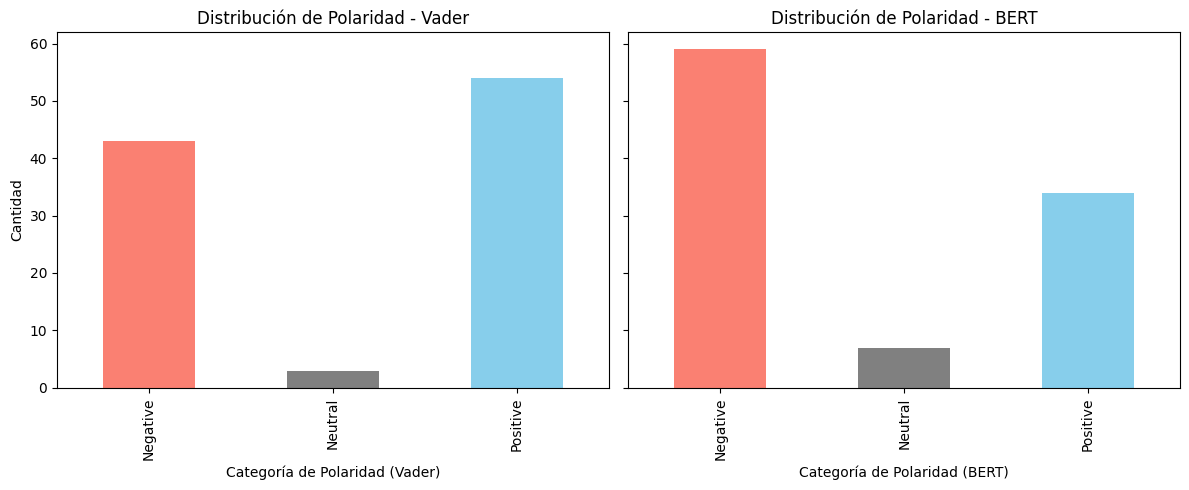

In [8]:
# Calcular la cantidad de reseñas por cada categoría para Vader y Bert
category_counts_vader = small_sample['vader_sentiment'].value_counts()
category_counts_bert = small_sample['bert_sentiment'].value_counts()

# Crear una tabla combinada para comparar las cantidades
category_counts = pd.DataFrame({
    'Vader Sentiment': category_counts_vader,
    'Bert Sentiment': category_counts_bert
}).fillna(0)

# Mostrar la tabla combinada
print("Tabla Comparativa de Categorías:")
print(category_counts)


print ("_________________________________________________________________________________________\n")

# Definir colores consistentes para cada categoría
colors = {'Negative': 'salmon', 'Neutral': 'gray', 'Positive': 'skyblue'}

# Crear gráficos lado a lado para Vader y BERT
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Gráfico para Vader
small_sample['vader_sentiment'].value_counts().reindex(colors.keys()).plot(
    kind='bar', color=[colors[cat] for cat in colors.keys()], ax=axes[0]
)
axes[0].set_title('Distribución de Polaridad - Vader')
axes[0].set_xlabel('Categoría de Polaridad (Vader)')
axes[0].set_ylabel('Cantidad')

# Gráfico para BERT
small_sample['bert_sentiment'].value_counts().reindex(colors.keys()).plot(
    kind='bar', color=[colors[cat] for cat in colors.keys()], ax=axes[1]
)
axes[1].set_title('Distribución de Polaridad - BERT')
axes[1].set_xlabel('Categoría de Polaridad (BERT)')

# Mostrar los gráficos
plt.tight_layout()
plt.show()

En el gráfico de VADER, se observa que la mayoría de las reseñas son clasificadas como positivas, seguidas de las negativas, mientras que las reseñas neutrales son mínimas. Mientras que en el grafico de BERT, se observa mas reseñas negativas que en el grafico de VADER. Ademas muestra mas datos neutrales, este comportamiento podría indicar que BERT, al ser un modelo más sofisticado, es capaz de identificar una gama más amplia de matices en las reseñas, lo que da lugar a un mayor número de clasificaciones neutrales.


Observaremos las filas donde las predicciones de Vader y Bert son diferentes



In [9]:
differences = small_sample[small_sample['vader_sentiment'] != small_sample['bert_sentiment']]

# Mostrar las diferencias
print("Número de diferencias:", len(differences))
differences[['customer_review', 'vader_sentiment', 'bert_sentiment']]

Número de diferencias: 25


,customer_review,vader_sentiment,bert_sentiment
5174,"Honolulu to San Diego August 23, 2018 I was f...",Positive,Negative
16742,5/28/15 PVD-ATL-CAE 6/1/15 CAE-ATL-PVD. Flight...,Negative,Neutral
4755,Columbia to Tokyo via Denver. I checked into ...,Positive,Neutral
6087,I had a flight scheduled for Sept 5th 2017 fr...,Neutral,Negative
2698,Weather may have been the initial cause of th...,Positive,Negative
5001,SFO-SEA-SFO. A320 + B737/900. Late on departur...,Negative,Neutral
16484,"When we were looking for a cheap flight, it wa...",Positive,Neutral
2954,Airlines like Delta don't actually care about...,Positive,Negative
8064,We flew from Las Vegas to JFK New York on 23rd...,Positive,Negative
15097,The United Airlines flight from Nashville to H...,Positive,Negative


Este es uno de los casos donde hay una diferencia entre el analisis de sentimiento con VADER y BERT. Se puede observar  claramente que esta reseña es extremadamente negativa.



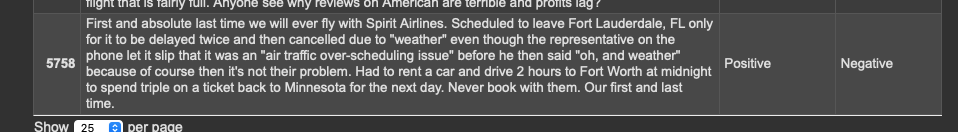



Revisé las 25 filas donde los resultados de vader_sentiment y bert_sentiment fueron diferentes. Después de analizar los casos, considero que de forma general el modelo de BERT es más preciso en la clasificación. Esto se debe a que BERT parece captar mejor los matices en las reseñas, especialmente cuando el sentimiento no es explícito o cuando hay una combinación de aspectos positivos y negativos en el texto. Aunque algunos resultados pueden ser discutibles, en la mayoría de los casos BERT ofrece una interpretación más alineada con el contenido de las reseñas.

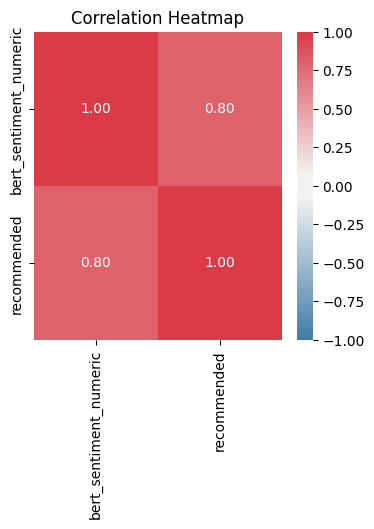

In [10]:
small_sample['bert_sentiment_numeric'] = small_sample['bert_sentiment'].map({'Negative': -1, 'Neutral': 0, 'Positive': 1})
corr_values = small_sample[['bert_sentiment_numeric','recommended']].dropna(axis=0,how='any').corr()

plt.figure(figsize=(4, 4))
cmap = sns.diverging_palette(240, 10, sep=20, as_cmap=True)
sns.heatmap(corr_values, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

El gráfico muestra una correlación de 0.80 entre la variable de sentimiento de BERT y la variable objetivo recommended, lo que indica una fuerte relación positiva. Esto sugiere que el análisis de sentimientos con BERT está estrechamente relacionado con la recomendación del servicio.

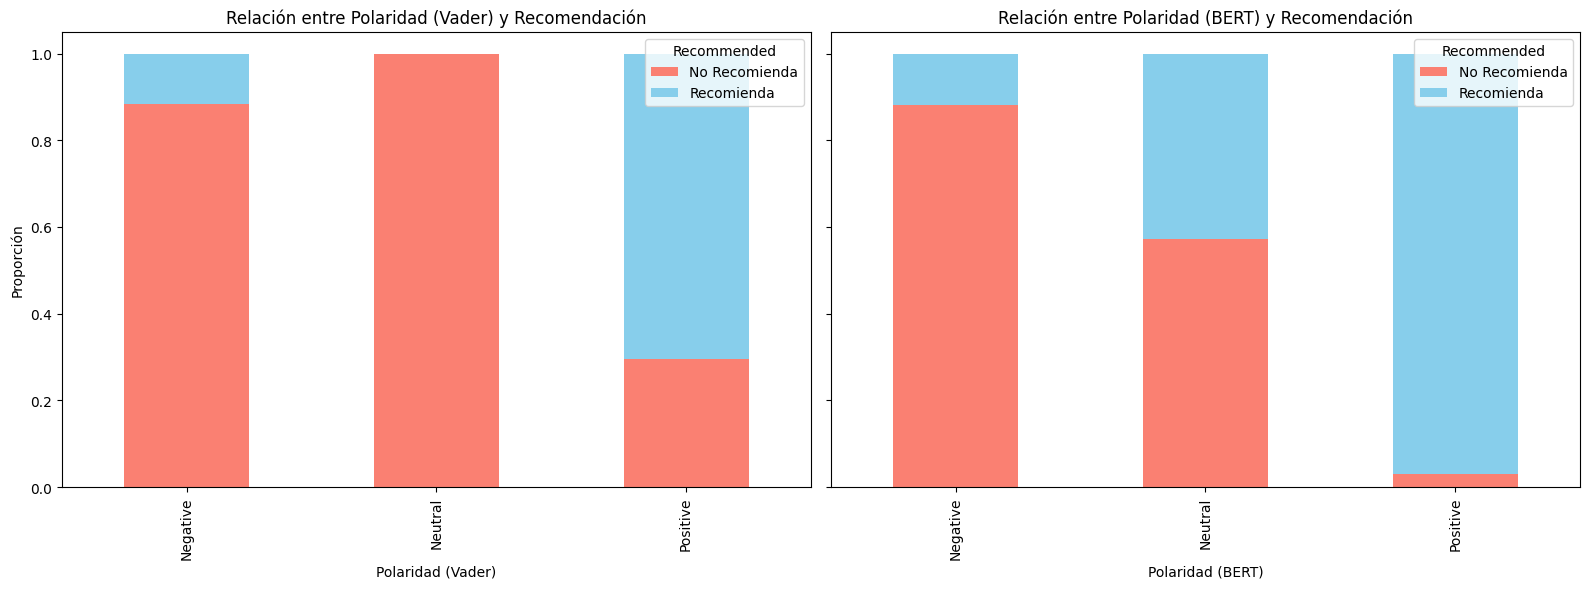

In [11]:
# Crear gráficos lado a lado para la relación entre polaridad y recomendación
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Relación para Vader
relation_vader_recommended = pd.crosstab(
    small_sample['vader_sentiment'],
    small_sample['recommended'],
    normalize='index'
)
relation_vader_recommended.plot(kind='bar', stacked=True, ax=axes[0], color=['salmon', 'skyblue'])
axes[0].set_title('Relación entre Polaridad (Vader) y Recomendación')
axes[0].set_xlabel('Polaridad (Vader)')
axes[0].set_ylabel('Proporción')
axes[0].legend(['No Recomienda', 'Recomienda'], title='Recommended')

# Relación para BERT
relation_bert_recommended = pd.crosstab(
    small_sample['bert_sentiment'],
    small_sample['recommended'],
    normalize='index'
)
relation_bert_recommended.plot(kind='bar', stacked=True, ax=axes[1], color=['salmon', 'skyblue'])
axes[1].set_title('Relación entre Polaridad (BERT) y Recomendación')
axes[1].set_xlabel('Polaridad (BERT)')
axes[1].legend(['No Recomienda', 'Recomienda'], title='Recommended')

plt.tight_layout()
plt.show()

**Relación entre Polaridad y Recomendación**

El análisis de la relación entre la polaridad de las reseñas y la recomendación muestra diferencias clave entre VADER y BERT. VADER muestra una fuerte correlación entre reseñas negativas y la falta de recomendación, pero también clasifica todas las reseñas neutrales como "No Recomienda", lo que podría subestimar la polaridad negativa. Las reseñas positivas, aunque correlacionadas con la recomendación, no tienen una proporción tan alta en comparación con las negativas para "No Recomienda".

Por otro lado, BERT captura mejor los matices, mostrando una mayor proporción de reseñas positivas recomendando el servicio. Además, las reseñas neutrales tienen un balance más equitativo entre "Recomienda" y "No Recomienda", reflejando una interpretación más precisa de los tonos mixtos.

**Comparación General:**

Ambos modelos coinciden en que las reseñas negativas tienen un alto impacto en la falta de recomendación, pero BERT es más preciso al distinguir entre las categorías de polaridad y manejar reseñas neutrales. VADER, al sobreclasificar reseñas negativas como neutrales, puede no captar bien las emociones reales de los clientes.

Este análisis se repetirá utilizando una muestra de mayor tamaño. En mi caso, solo se realizó una única ejecución debido a las limitaciones de hardware, ya que mi equipo no cuenta con una GPU adecuada para procesar grandes volúmenes de datos de manera eficiente.

In [12]:
df_sentiments = dataframe_original.copy()

In [13]:
# Descargar recursos de NLTK necesarios
nltk.download('vader_lexicon')

# Inicializamos el analizador de sentimientos
sid = SentimentIntensityAnalyzer()

# Calcular puntajes de polaridad para cada reseña en el dataset
df_sentiments['vader_polarity'] = df_sentiments['customer_review'].apply(lambda x: sid.polarity_scores(str(x))['compound'])
#llamar a la funcion "classify_polarity"
df_sentiments['vader_sentiment'] = df_sentiments['vader_polarity'].apply(classify_polarity)

df_sentiments[['customer_review', 'vader_sentiment']].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,customer_review,vader_sentiment
0,Due to fly Spirit Airlines from Costa Rica to ...,Negative
1,This awful experience is happening too Often ...,Positive
2,Flew American Airlines from Madison to Salt L...,Positive
3,Flew Detroit to Las Vegas with Delta Air Line...,Negative
4,Harrisburg to Philadelphia. This was the wors...,Negative


In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import torch
from tqdm import tqdm

# Cargar el tokenizador y modelo preentrenado
tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")
model = AutoModelForSequenceClassification.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")

# Definir la función para realizar inferencia
def bert_inference(df_sentiments):
    model.eval()
    predictions = []

   # Procesar en lotes (ajusta el tamaño según tu hardware)
    for i in tqdm(range(0, len(df_sentiments), 32), desc="Inferencia de Sentimientos BERT"):
        batch_reviews = df_sentiments['customer_review'].iloc[i:i+32].tolist()
        tokens = tokenizer(
            batch_reviews,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        # Realizar inferencia
        with torch.no_grad():
            outputs = model(**tokens)
            logits = outputs.logits  # Valores en bruto del modelo
            print("Logits:", logits)  # Ver logits para depuración

            probs = softmax(logits, dim=1)  # Convertir logits a probabilidades
            print("Probabilidades:", probs)  # Ver probabilidades

            batch_predictions = torch.argmax(probs, axis=1).numpy()
            predictions.extend(batch_predictions)

    return predictions

# Ejecutar la inferencia con el dataset
bert_predictions = bert_inference(df_sentiments)

# Mapear los resultados a etiquetas de sentimiento
sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
df_sentiments['bert_sentiment'] = [sentiment_map[pred] for pred in bert_predictions]

df_sentiments[['customer_review', 'bert_sentiment']]

Inferencia de Sentimientos BERT:   0%|          | 1/536 [00:13<2:02:23, 13.73s/it]

Logits: tensor([[ 1.0845,  0.7351, -1.8141],
        [ 3.0636, -0.2998, -2.8504],
        [ 1.0387,  0.4569, -1.4288],
        [ 3.0583, -0.5044, -2.5843],
        [ 3.2173, -0.5045, -2.6934],
        [ 2.6628, -0.3193, -2.3335],
        [ 3.2576, -0.6653, -2.6202],
        [ 2.0951,  0.1160, -2.2450],
        [ 2.5790, -0.2629, -2.3332],
        [ 2.3110, -0.0168, -2.3046],
        [ 1.9307,  0.1621, -2.1494],
        [ 1.4335,  0.3133, -1.7368],
        [-1.2101,  0.6701,  0.6353],
        [ 1.9798, -0.2399, -1.8315],
        [ 0.9075,  0.6096, -1.5569],
        [ 2.1378, -0.2373, -1.9962],
        [ 0.7901,  0.4209, -1.2971],
        [ 1.7538, -0.0824, -1.6268],
        [ 0.0812,  0.4056, -0.4521],
        [ 2.4950, -0.1415, -2.4096],
        [ 1.6887,  0.2983, -2.0669],
        [ 2.2437, -0.2245, -2.1003],
        [ 1.8426, -0.0035, -1.8826],
        [ 2.4682, -0.0540, -2.4098],
        [-0.2997,  0.1843,  0.1933],
        [ 2.1707, -0.2296, -1.9669],
        [ 2.3762, -0.0430, -2.

Inferencia de Sentimientos BERT:   0%|          | 2/536 [00:28<2:06:09, 14.18s/it]

Logits: tensor([[-0.8451,  0.5839,  0.2781],
        [ 2.3965, -0.1417, -2.3361],
        [ 1.0196, -0.0091, -1.0614],
        [ 0.8866,  0.3991, -1.3254],
        [ 2.6349, -0.2729, -2.3813],
        [ 1.4353, -0.0490, -1.4214],
        [ 1.5387,  0.1133, -1.6664],
        [ 3.4231, -0.7240, -2.7603],
        [ 1.7851,  0.1126, -1.8868],
        [ 1.9949,  0.0633, -2.0519],
        [ 2.7813, -0.3168, -2.5241],
        [ 2.5449, -0.2095, -2.4314],
        [ 1.6612,  0.0918, -1.8414],
        [ 3.0279, -0.5316, -2.4139],
        [ 1.5312, -0.1103, -1.3903],
        [ 2.8475, -0.4426, -2.4256],
        [ 0.6472,  0.3369, -0.9873],
        [ 0.6838,  0.6907, -1.4090],
        [ 2.6461, -0.4076, -2.3029],
        [ 0.7332,  0.5418, -1.1973],
        [ 2.3623, -0.0549, -2.2992],
        [ 2.2872, -0.1816, -2.1660],
        [ 3.1263, -0.4574, -2.6971],
        [ 2.5294, -0.2250, -2.3133],
        [ 2.3354, -0.0460, -2.3722],
        [ 2.0359, -0.1511, -1.8895],
        [ 2.4179,  0.0563, -2.

Inferencia de Sentimientos BERT:   1%|          | 3/536 [00:41<2:03:52, 13.94s/it]

...

Inferencia de Sentimientos BERT: 100%|█████████▉| 535/536 [2:05:13<00:14, 14.09s/it]

Logits: tensor([[-2.5441e+00, -1.8108e-01,  3.2878e+00],
        [-1.1868e+00, -1.2569e-01,  1.5967e+00],
        [-1.9911e+00, -8.3956e-02,  2.4802e+00],
        [-2.4697e+00, -6.1225e-02,  3.1204e+00],
        [ 3.1025e+00, -3.5965e-01, -2.7701e+00],
        [-2.7256e+00, -2.0249e-01,  3.5050e+00],
        [ 9.2809e-01,  3.3877e-01, -1.2951e+00],
        [-2.6208e+00, -3.9118e-01,  3.6674e+00],
        [-1.2070e+00,  3.1410e-01,  9.9407e-01],
        [-1.9773e+00,  6.6233e-01,  1.4589e+00],
        [-2.4300e+00, -7.5638e-02,  3.0181e+00],
        [ 2.1784e-02,  5.8684e-03,  1.2814e-01],
        [-1.4643e+00, -1.9751e-02,  1.7889e+00],
        [-2.7925e+00, -1.5602e-01,  3.5320e+00],
        [-1.7016e+00, -2.7519e-01,  2.4718e+00],
        [-1.7587e+00, -1.8056e-01,  2.3663e+00],
        [-2.9706e+00,  5.9861e-01,  2.7399e+00],
        [-1.3719e+00,  1.0187e-01,  1.4509e+00],
        [-2.9576e+00,  1.7960e-01,  3.1873e+00],
        [-1.4230e+00, -2.0109e-01,  2.0407e+00],
        [-1.

Inferencia de Sentimientos BERT: 100%|██████████| 536/536 [2:05:26<00:00, 14.04s/it]

Logits: tensor([[-1.3973e+00, -7.4207e-02,  1.7548e+00],
        [-7.2865e-01,  2.3049e-01,  5.4259e-01],
        [ 1.2561e+00,  3.2972e-01, -1.6736e+00],
        [-1.8955e+00,  2.6749e-01,  1.9177e+00],
        [ 1.6758e+00,  1.3300e-01, -1.8590e+00],
        [-1.2109e+00, -3.7203e-02,  1.4987e+00],
        [-1.4955e+00,  2.6843e-01,  1.3956e+00],
        [-1.9314e+00,  3.8067e-03,  2.2525e+00],
        [-9.3422e-01,  1.7321e-01,  8.8043e-01],
        [-1.1010e+00,  5.5554e-01,  5.4413e-01],
        [-2.0913e+00, -7.4352e-02,  2.5047e+00],
        [-2.4237e+00,  2.1945e-01,  2.5480e+00],
        [-2.6301e+00, -2.2494e-01,  3.4242e+00],
        [ 5.1708e-01,  3.0140e-01, -8.4879e-01],
        [ 1.7373e+00,  1.4657e-01, -1.9024e+00],
        [-1.8050e+00, -3.3586e-01,  2.5994e+00],
        [-1.6499e+00,  3.6665e-02,  1.8945e+00],
        [-4.2900e-02,  1.2716e-01, -5.7541e-02],
        [-2.5031e+00, -6.6188e-01,  3.9298e+00],
        [ 2.6723e+00, -4.6393e-01, -2.2754e+00],
        [-9.

,customer_review,bert_sentiment
0,Due to fly Spirit Airlines from Costa Rica to ...,Negative
1,This awful experience is happening too Often ...,Negative
2,Flew American Airlines from Madison to Salt L...,Negative
3,Flew Detroit to Las Vegas with Delta Air Line...,Negative
4,Harrisburg to Philadelphia. This was the wors...,Negative
...,...,...
17145,I normally rant about my detinU Airlines fligh...,Positive
17146,We felt safe and cared for. The flight attenda...,Positive
17147,Orlando to Denver to Edmonton - because we had...,Neutral
17148,San Francisco to Atlanta in First Class on a ...,Positive


Tabla Comparativa de Categorías:
          Vader Sentiment  Bert Sentiment
Negative             6794            8386
Neutral               424            1619
Positive             9932            7145
_________________________________________________________________________________________



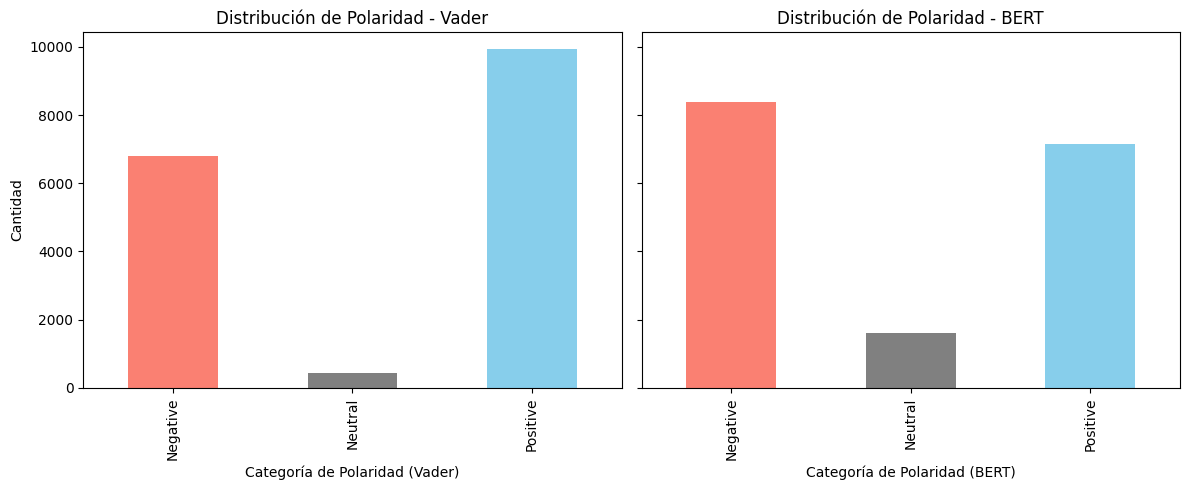

In [15]:
 # Calcular la cantidad de reseñas por cada categoría para Vader y Bert
category_counts_vader = df_sentiments['vader_sentiment'].value_counts()
category_counts_bert = df_sentiments['bert_sentiment'].value_counts()

# Crear una tabla combinada para comparar las cantidades
category_counts = pd.DataFrame({
    'Vader Sentiment': category_counts_vader,
    'Bert Sentiment': category_counts_bert
}).fillna(0)

# Mostrar la tabla combinada
print("Tabla Comparativa de Categorías:")
print(category_counts)

print("_________________________________________________________________________________________\n")

# Definir colores consistentes para cada categoría
colors = {'Negative': 'salmon', 'Neutral': 'gray', 'Positive': 'skyblue'}

# Crear gráficos lado a lado para Vader y BERT
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Gráfico para Vader
df_sentiments['vader_sentiment'].value_counts().reindex(colors.keys()).plot(
     kind='bar', color=[colors[cat] for cat in colors.keys()], ax=axes[0]
)
axes[0].set_title('Distribución de Polaridad - Vader')
axes[0].set_xlabel('Categoría de Polaridad (Vader)')
axes[0].set_ylabel('Cantidad')

# Gráfico para BERT
df_sentiments['bert_sentiment'].value_counts().reindex(colors.keys()).plot(
    kind='bar', color=[colors[cat] for cat in colors.keys()], ax=axes[1]
)
axes[1].set_title('Distribución de Polaridad - BERT')
axes[1].set_xlabel('Categoría de Polaridad (BERT)')

# Mostrar los gráficos
plt.tight_layout()
plt.show()

In [16]:
# Identificar las filas donde las predicciones de Vader y Bert son diferentes
differences = df_sentiments[df_sentiments['vader_sentiment'] != df_sentiments['bert_sentiment']]

print("Número de diferencias:", len(differences))

Número de diferencias: 4279


In [17]:

differences[['customer_review', 'vader_sentiment', 'bert_sentiment']]

,customer_review,vader_sentiment,bert_sentiment
1,This awful experience is happening too Often ...,Positive,Negative
2,Flew American Airlines from Madison to Salt L...,Positive,Negative
11,I flew Frontier from SFO-MSY. I had to pay for...,Positive,Negative
12,Chicago to Las Vegas. We bought one way ticke...,Positive,Neutral
15,Having just flown American Airlines for the fi...,Positive,Negative
...,...,...,...
17134,Flying out of Las Vegas is often a depressing ...,Positive,Negative
17137,Flew from New York-JFK to Charlotte with Ameri...,Positive,Neutral
17140,Flew MAN-ATL-HNL and LIH-LAX-ATL-MAN in Busine...,Negative,Positive
17144,The gross difference in cost for a first class...,Positive,Neutral


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


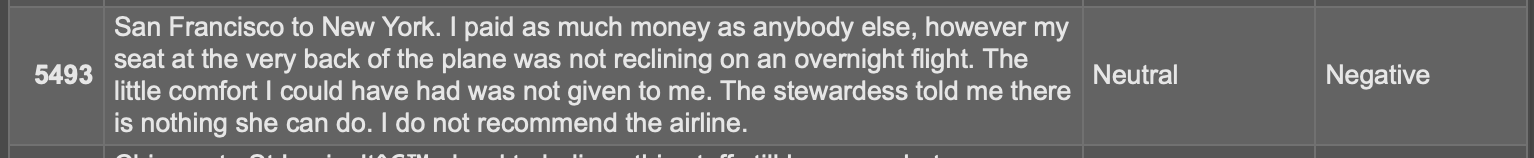



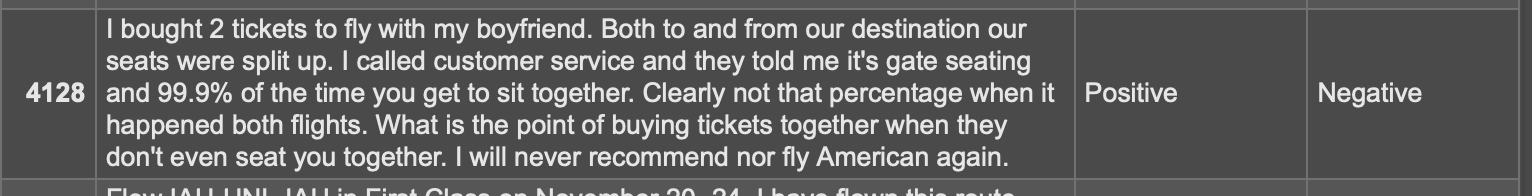

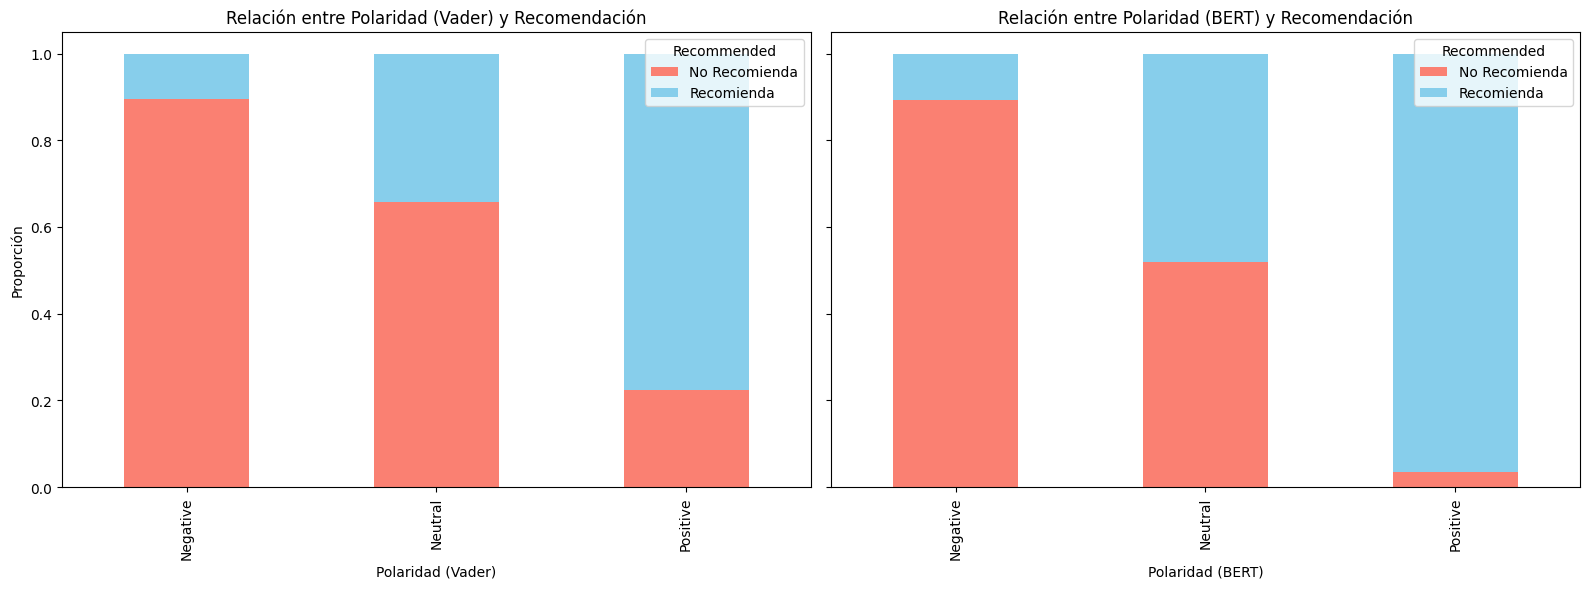

In [18]:
# Crear gráficos lado a lado para la relación entre polaridad y recomendación
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Relación para Vader
relation_vader_recommended = pd.crosstab(
    df_sentiments['vader_sentiment'],
    df_sentiments['recommended'],
    normalize='index'
)
relation_vader_recommended.plot(kind='bar', stacked=True, ax=axes[0], color=['salmon', 'skyblue'])
axes[0].set_title('Relación entre Polaridad (Vader) y Recomendación')
axes[0].set_xlabel('Polaridad (Vader)')
axes[0].set_ylabel('Proporción')
axes[0].legend(['No Recomienda', 'Recomienda'], title='Recommended')

# Relación para BERT
relation_bert_recommended = pd.crosstab(
    df_sentiments['bert_sentiment'],
    df_sentiments['recommended'],
    normalize='index'
)
relation_bert_recommended.plot(kind='bar', stacked=True, ax=axes[1], color=['salmon', 'skyblue'])
axes[1].set_title('Relación entre Polaridad (BERT) y Recomendación')
axes[1].set_xlabel('Polaridad (BERT)')
axes[1].legend(['No Recomienda', 'Recomienda'], title='Recommended')

plt.tight_layout()
plt.show()

**Análisis de Polaridad y Recomendación**  

Basandonos en la base entera, se puede observar patrones más robustos y representativos en la relación entre polaridad y recomendación del servicio. A diferencia del primer análisis, realizado con una muestra de 100 datos, este gráfico muestra una mayor consistencia en las proporciones, reduciendo el impacto de posibles sesgos estadísticos debido al tamaño reducido de la muestra inicial.  

En esta muestra ampliada, se observa una mejora en el modelo VADER, pero sigue teniendo mejores respuestas el modelo con BERT.  

Este análisis evidencia cómo un mayor tamaño de muestra refuerza la confiabilidad de los resultados y permite identificar tendencias con mayor precisión.

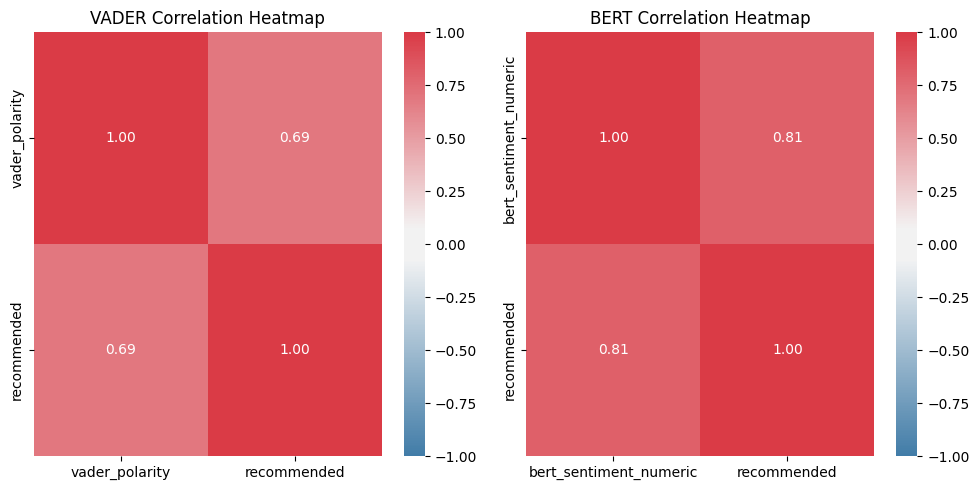

In [19]:



# Convertir valores de 'bert_sentiment' a numéricos
df_sentiments['bert_sentiment_numeric'] = df_sentiments['bert_sentiment'].map({'Negative': -1, 'Neutral': 0, 'Positive': 1})

# Crear los dos heatmaps en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Heatmap de VADER
corr_values_vader = df_sentiments[['vader_polarity', 'recommended']].dropna(axis=0, how='any').corr()
sns.heatmap(corr_values_vader, annot=True, fmt=".2f", cmap=sns.diverging_palette(240, 10, sep=20, as_cmap=True),
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("VADER Correlation Heatmap")

# Heatmap de BERT
corr_values_bert = df_sentiments[['bert_sentiment_numeric', 'recommended']].dropna(axis=0, how='any').corr()
sns.heatmap(corr_values_bert, annot=True, fmt=".2f", cmap=sns.diverging_palette(240, 10, sep=20, as_cmap=True),
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("BERT Correlation Heatmap")

# Mostrar los gráficos
plt.tight_layout()
plt.show()

Se confirma la mejora de los dos modelos. mejoro mucho mas el modelo VADER que BERT

In [20]:
df_sentiments.to_csv('df_sentiments_total.csv', index=False)

In [21]:
df_sentiments

,airline,overall,author,review_dayofweek,review_month,review_year,flight_dayofweek,flight_month,flight_year,days_since_flight,...,country_destin,continent_destin,coordinates_destin,airport_classification_destin,route_distance,route_time_minutes,vader_polarity,vader_sentiment,bert_sentiment,bert_sentiment_numeric
0,Spirit Airlines,1.0,Author 7725,3,11,2016,4,11.0,2016.0,6,...,United States,North America,"(26.072599, -80.152702)",National,1830.352578,137.0,-0.8059,Negative,Negative,-1
1,American Airlines,3.0,Author 275,6,4,2018,2,4.0,2018.0,11,...,Colombia,South America,"(4.70159, -74.1469)",International,3908.314132,293.0,0.2120,Positive,Negative,-1
2,American Airlines,3.0,Author 992,3,9,2018,5,9.0,2018.0,5,...,United States,North America,"(40.78839874267578, -111.97799682617188)",National,1889.023000,142.0,0.5859,Positive,Negative,-1
3,Delta Air Lines,1.0,Author 2958,2,5,2017,0,5.0,2017.0,9,...,United States,North America,"(36.08010101, -115.1520004)",National,2814.248172,211.0,-0.8781,Negative,Negative,-1
4,American Airlines,1.0,Author 859,6,5,2018,1,5.0,2018.0,5,...,United States,North America,"(39.87189865112305, -75.24109649658203)",National,134.748672,10.0,-0.6239,Negative,Negative,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17145,United Airlines,9.0,Synthetic_Author_2571,2,9,2015,1,9.0,2015.0,8,...,United States,North America,"(26.68320083618164, -80.09559631347656)",National,1647.116256,124.0,0.9893,Positive,Positive,1
17146,Spirit Airlines,8.0,Synthetic_Author_2028,5,5,2018,2,5.0,2018.0,10,...,United States,North America,"(28.429399490356445, -81.30899810791016)",National,1816.226700,136.0,0.9465,Positive,Positive,1
17147,United Airlines,9.0,Synthetic_Author_2227,4,1,2014,3,1.0,2014.0,8,...,United States,North America,"(39.861698150635, -104.672996521)",National,2488.774863,187.0,0.9596,Positive,Neutral,0
17148,Delta Air Lines,8.0,Author 3037,6,12,2016,0,12.0,2016.0,6,...,United States,North America,"(33.6367, -84.428101)",National,3442.220346,258.0,0.9538,Positive,Positive,1


## ANALISIS DE TOPICOS

---



In [22]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import GridSearchCV
import textwrap

In [23]:
contractions = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot", "can't've": "cannot have",
    "'cause": "because", "could've": "could have", "couldn't": "could not", "didn't": "did not",
    "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would", "he'll": "he will", "he's": "he is",
    "how'd": "how did", "how's": "how is", "i'd": "i would", "i'm": "i am",
    "i've": "i have", "isn't": "is not", "it's": "it is", "let's": "let us",
    "she'd": "she would", "she'll": "she will", "she's": "she is",
    "should've": "should have", "shouldn't": "should not", "that's": "that is",
    "there's": "there is", "they'd": "they would", "they're": "they are",
    "they've": "they have", "wasn't": "was not", "we'd": "we would",
    "we're": "we are", "we've": "we have", "weren't": "were not",
    "what's": "what is", "where's": "where is", "who's": "who is",
    "won't": "will not", "wouldn't": "would not", "you'd": "you would",
    "you're": "you are", "you've": "you have"}

In [24]:
#df_sentiments = pd.read_csv('/content/df_sentiments.csv')

In [25]:
# Función para expandir contracciones
def expand_contractions(text, contractions):
    pattern = re.compile(r'\b(' + '|'.join(re.escape(key) for key in contractions.keys()) + r')\b')
    return pattern.sub(lambda x: contractions.get(x.group(0), x.group(0)), text)

# Preprocesamiento del texto
def preprocess_text(text, stop_words, contractions):
    text = expand_contractions(text, contractions)
    # Agregar el manejo del signo €™ y otros caracteres no alfabéticos
    text = re.sub(r'[^a-zA-Z\s€™]', '', text).lower()
    tokens = word_tokenize(text)
    return ' '.join([word for word in tokens if word not in stop_words])

# Crear matriz de términos
def create_term_matrix(data, max_df=0.95, min_df=2):
    vectorizer = CountVectorizer(max_df=max_df, min_df=min_df, stop_words='english')
    term_matrix = vectorizer.fit_transform(data)
    return term_matrix, vectorizer

# Aplicar LDA y buscar mejores parámetros
def apply_lda(term_matrix, search_params, random_state=42):
    grid_search = GridSearchCV(LatentDirichletAllocation(random_state=random_state), param_grid=search_params, cv=3)
    grid_search.fit(term_matrix)
    return grid_search.best_estimator_, grid_search.best_params_['n_components']

# Mostrar tópicos con ejemplos y ajustar longitud de líneas
def display_topics_with_wrapped_examples(topics, examples, wrap_width=80):
    print("=" * 80)
    print("RESULTADOS DE ANÁLISIS DE TÓPICOS")
    print("=" * 80)
    for topic, words in topics.items():
        print(f"\n{topic}:")
        print(f"Palabras clave: {', '.join(words)}")
        example = examples.get(topic, 'No hay ejemplo disponible.')
        wrapped_example = "\n".join(textwrap.wrap(example, width=wrap_width))
        print(f"Ejemplo representativo:\n{wrapped_example}")
    print("=" * 80)

# Mostrar tópicos
def display_topics(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx + 1}"] = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
    return topics

# Calcular correlación entre tópicos y variables externas
def analyze_topic_correlation(df, lda_model, vectorizer):
    print("Analizando correlación entre tópicos y variables externas...")
    topic_matrix = lda_model.transform(vectorizer.transform(df['cleaned_review']))
    df_topics = pd.DataFrame(topic_matrix, columns=[f'Topic_{i+1}' for i in range(lda_model.n_components)])
    return pd.concat([df.reset_index(drop=True), df_topics], axis=1)

### ------------------    UNITED AIRLINES    ------------------

Se filtraran unicamente las filas con valores "Negative" y "Positive" de la columna bert_sentiment

In [26]:
# Definir stopwords personalizadas
custom_stop_words = set(stopwords.words('english')).union({'flight', 'united', 'airline', 'plane', 'airlines', 'flights'})

# Aplicar preprocesamiento
print("Preprocesando texto...")
df_sentiments['cleaned_review'] = df_sentiments['customer_review'].apply(lambda x: preprocess_text(x, custom_stop_words, contractions))

# Filtrar reviews negativas y positivas
df_negative = df_sentiments[(df_sentiments['bert_sentiment'] == 'Negative') & (df_sentiments['airline'] == 'United Airlines')]
df_positive = df_sentiments[(df_sentiments['bert_sentiment'] == 'Positive') & (df_sentiments['airline'] == 'United Airlines')]

# Crear matrices de términos
print("Creando matriz de términos...")
term_matrix_negative, vectorizer_negative = create_term_matrix(df_negative['cleaned_review'])
term_matrix_positive, vectorizer_positive = create_term_matrix(df_positive['cleaned_review'])

# Parámetros de búsqueda para LDA
search_params = {'n_components': [2, 3, 5], 'learning_decay': [0.5, 0.7, 0.9]}

# Aplicar LDA a reviews negativas
if term_matrix_negative.shape[0] > 0:
    print("_" * 50)
    print("RESEÑAS NEGATIVAS")
    print("Aplicando LDA a reviews negativas...")
    best_lda_negative, n_topics_negative = apply_lda(term_matrix_negative, search_params)
    print(f"Mejor cantidad de tópicos para reviews negativas: {n_topics_negative}")
    print(display_topics)  # Comprobación para verificar si la función está definida
    topics_negative = display_topics(best_lda_negative, vectorizer_negative.get_feature_names_out(), 20)
    examples_negative = {f"Topic {i+1}": df_negative.iloc[np.argmax(best_lda_negative.transform(term_matrix_negative)[:, i])]['customer_review'] for i in range(n_topics_negative)}
    display_topics_with_wrapped_examples(topics_negative, examples_negative)
    df_negative_topics = analyze_topic_correlation(df_negative, best_lda_negative, vectorizer_negative)
else:
    print("No hay suficientes datos para análisis de tópicos en reviews negativas.")

# Aplicar LDA a reviews positivas
if term_matrix_positive.shape[0] > 0:
    print("_" * 50)
    print("RESEÑAS POSITIVAS")
    print("Aplicando LDA a reviews positivas...")
    best_lda_positive, n_topics_positive = apply_lda(term_matrix_positive, search_params)
    print(f"Mejor cantidad de tópicos para reviews positivas: {n_topics_positive}")
    topics_positive = display_topics(best_lda_positive, vectorizer_positive.get_feature_names_out(), 20)
    examples_positive = {f"Topic {i+1}": df_positive.iloc[np.argmax(best_lda_positive.transform(term_matrix_positive)[:, i])]['customer_review'] for i in range(n_topics_positive)}
    display_topics_with_wrapped_examples(topics_positive, examples_positive)
    df_positive_topics = analyze_topic_correlation(df_positive, best_lda_positive, vectorizer_positive)
else:
    print("No hay suficientes datos para análisis de tópicos en reviews positivas.")

Preprocesando texto...
Creando matriz de términos...
__________________________________________________
RESEÑAS NEGATIVAS
Aplicando LDA a reviews negativas...
Mejor cantidad de tópicos para reviews negativas: 2
<function display_topics at 0x7c1fed5eb6a0>
RESULTADOS DE ANÁLISIS DE TÓPICOS

Topic 1:
Palabras clave: hours, time, delayed, service, customer, airport, told, fly, chicago, hour, day, connecting, got, pm, gate, delay, san, cancelled, newark, luggage
Ejemplo representativo:
 Never flying United Airlines again. I recently took a trip from North Dakota to
Brisbane and back. United managed to ruin over 60% of my flights. It started on
my 2nd flight on the way there. The aircraft was delayed for almost 3 hours and
did not take off until it should have been landing in San Francisco. Not only
that we as customers were given different reasons as to the delays. One said too
much rain for 1.5 hours of the delay and the other said too much wind for the
other 1.5 hour delay. Landed in San 

Se ejemplifican los topicos con una reseña, ya que quizas las palabras no dicen mucho y falta contexto.

Se observa como en las reseñas positivas y negativas hay ciertos patrones, es decir para algunos pasajeros fue comodo y para otros no, es por ello, que es necesario observar mas en profundidad, en los distintos vuelos.

También puede pasar, que en un mismo vuelo, alguien tenga una buena experiencia y otro pasajero una mala experiencia. Es por esto, que se debe observar la repeticiencia, es decir, si en un mismo vuelo, se repite una critica, entonces es un factor a mejorar.

Nube de palabras

Generando nubes de palabras para tópicos negativos...


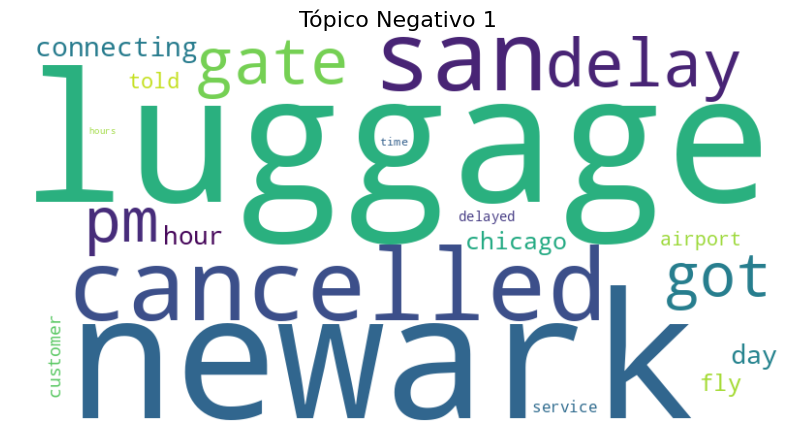

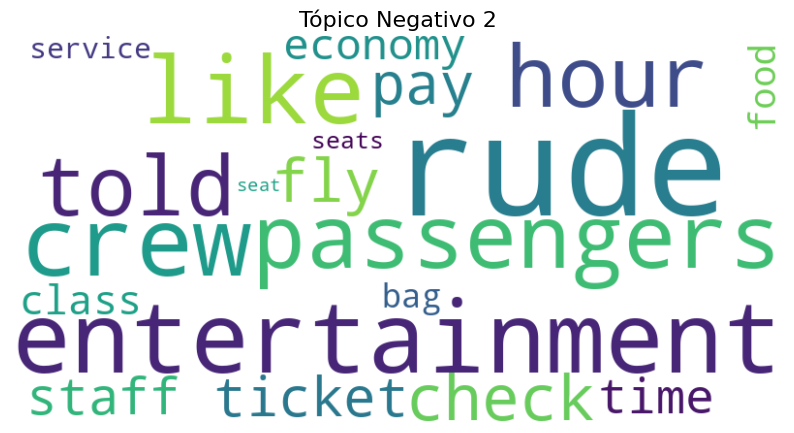

Generando nubes de palabras para tópicos positivos...


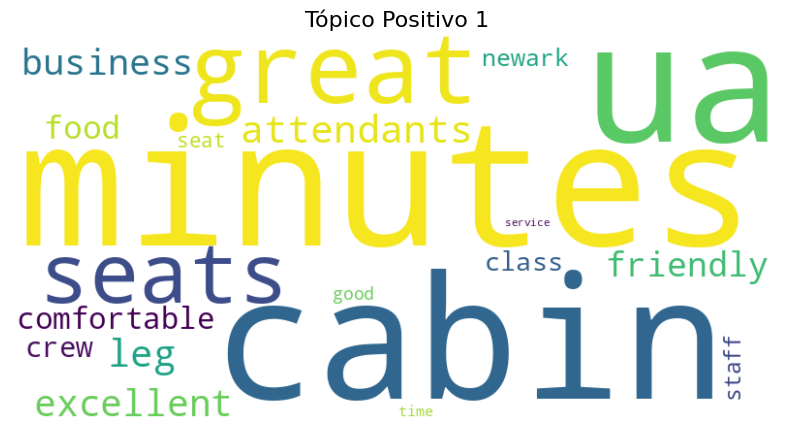

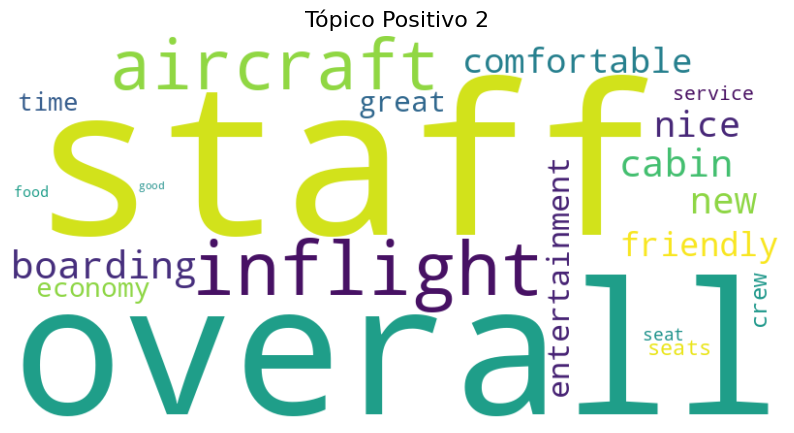

In [27]:
from wordcloud import WordCloud
def generate_word_clouds(topics, title_prefix="Tópico"):
    """
    Genera nubes de palabras para cada tópico.

    :param topics: Diccionario o lista con las palabras clave por tópico.
    :param title_prefix: Prefijo del título de las nubes de palabras.
    """
    if isinstance(topics, dict):
        topics = list(topics.values())  # Convertir a lista si es diccionario

    for i, topic_words in enumerate(topics):
        if isinstance(topic_words, str):  # Manejo si las palabras están en formato string
            topic_words = topic_words.split()  # Convertir string a lista
        elif not isinstance(topic_words, list):
            print(f"Formato inesperado en tópico {i + 1}: {topic_words}")
            continue

        # Crear el diccionario de frecuencia simulada
        word_freq = {word: freq for freq, word in enumerate(topic_words, 1)}
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

        plt.figure(figsize=(10, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"{title_prefix} {i+1}", fontsize=16)
        plt.axis("off")
        plt.show()

# Nubes de palabras para tópicos negativos
if 'topics_negative' in locals() and len(topics_negative) > 0:
    print("Generando nubes de palabras para tópicos negativos...")
    generate_word_clouds(topics_negative, title_prefix="Tópico Negativo")

# Nubes de palabras para tópicos positivos
if 'topics_positive' in locals() and len(topics_positive) > 0:
    print("Generando nubes de palabras para tópicos positivos...")
    generate_word_clouds(topics_positive, title_prefix="Tópico Positivo")



### --------------------  COMPETENCIA  --------------------

**American Airlines y Delta Air Lines**

In [28]:
# Definir stopwords personalizadas
custom_stop_words = set(stopwords.words('english')).union({'flight', 'united', 'airline', 'plane', 'airlines', 'flights',
                                                           'american', 'american airlines', 'americanair',
                                                           'delta', 'delta airlines', 'deltaair', "aa"})
# Aplicar preprocesamiento
print("Preprocesando texto...")
df_sentiments['cleaned_review'] = df_sentiments['customer_review'].apply(lambda x: preprocess_text(x, custom_stop_words, contractions))

# Filtrar reviews negativas y positivas por aerolínea
airlines = ['American Airlines', 'Delta Air Lines']
sentiments = ['Negative', 'Positive']

# Parámetros de búsqueda para LDA
search_params = {'n_components': [2, 3, 5], 'learning_decay': [0.5, 0.7, 0.9]}

for airline in airlines:
    for sentiment in sentiments:
        print("_" * 50)
        print(f"{sentiment.upper()} REVIEWS - {airline.upper()}")
        df_filtered = df_sentiments[(df_sentiments['bert_sentiment'] == sentiment) & (df_sentiments['airline'] == airline)]

        if not df_filtered.empty:
            print(f"Analizando {sentiment.lower()} reviews de {airline}...")
            term_matrix, vectorizer = create_term_matrix(df_filtered['cleaned_review'])

            if term_matrix.shape[0] > 0:
                best_lda, n_topics = apply_lda(term_matrix, search_params)
                print(f"Mejor cantidad de tópicos para {sentiment.lower()} reviews de {airline}: {n_topics}")
                topics = display_topics(best_lda, vectorizer.get_feature_names_out(), 20)
                examples = {f"Topic {i+1}": df_filtered.iloc[np.argmax(best_lda.transform(term_matrix)[:, i])]['customer_review'] for i in range(n_topics)}
                display_topics_with_wrapped_examples(topics, examples)
                df_topics = analyze_topic_correlation(df_filtered, best_lda, vectorizer)
            else:
                print(f"No hay suficientes datos para generar matriz de términos en {sentiment.lower()} reviews de {airline}.")
        else:
            print(f"No hay suficientes datos para análisis de tópicos en {sentiment.lower()} reviews de {airline}.")

Preprocesando texto...
__________________________________________________
NEGATIVE REVIEWS - AMERICAN AIRLINES
Analizando negative reviews de American Airlines...
Mejor cantidad de tópicos para negative reviews de American Airlines: 2
RESULTADOS DE ANÁLISIS DE TÓPICOS

Topic 1:
Palabras clave: time, hours, service, told, customer, delayed, gate, airport, fly, hour, dallas, got, day, minutes, connecting, check, said, experience, pm, people
Ejemplo representativo:
 First I'd like to start out saying that 20 years ago, I had the exact same
result as I did this past weekend and swore I would never fly American Airlines
again. I was returning to Houston from Salt Lake City, I had to go thru Dallas
for a connecting flight. My flight in Salt Lake City was delayed due to weather
issues originally. I knew I was going to miss my connecting flight in Dallas,
once I heard of the delay and got up in line (a long one at that) to be told to
call the 1-800 number to get done faster. When I spoke with 

Se observa un patrón: las principales críticas de las tres aerolíneas están relacionadas con malas experiencias debido a retrasos y deficiencias en la atención al cliente.

Es lógico que estos puntos sean los más recurrentes. Por ello, United debería enfocar su tiempo y recursos en mejorarlos para destacar. Esto incluye optimizar la logística para evitar retrasos o, en caso de ser inevitables, mejorar la comunicación y el trato hacia los clientes. Abordar estos factores podría generar una ventaja competitiva frente a las demás aerolíneas.

Generando nubes de palabras para negative reviews de American Airlines...


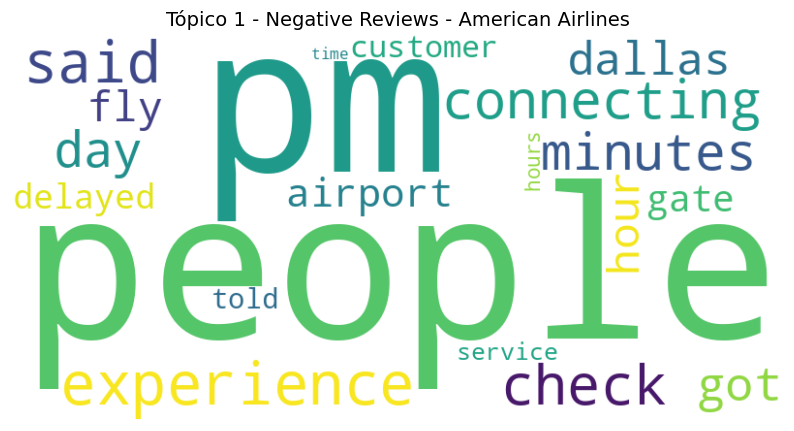

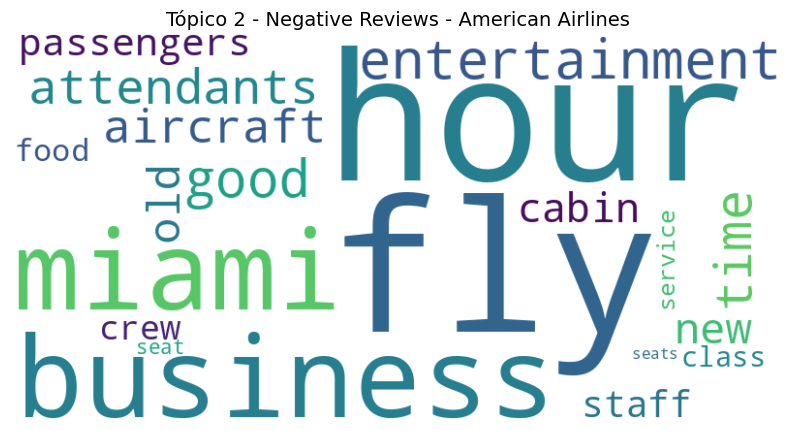

Generando nubes de palabras para positive reviews de American Airlines...


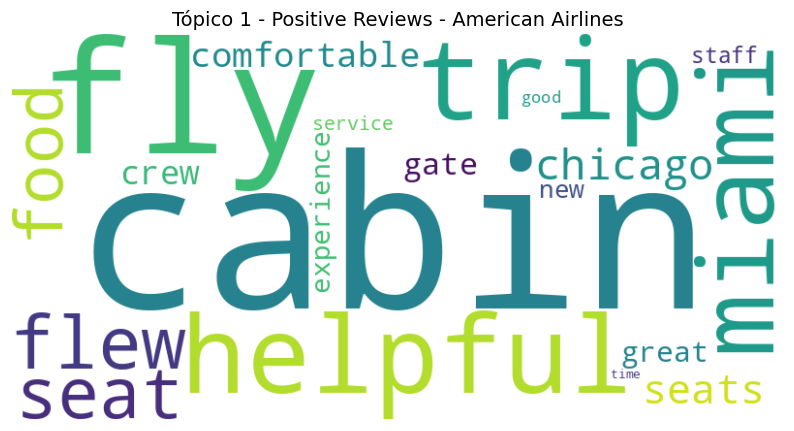

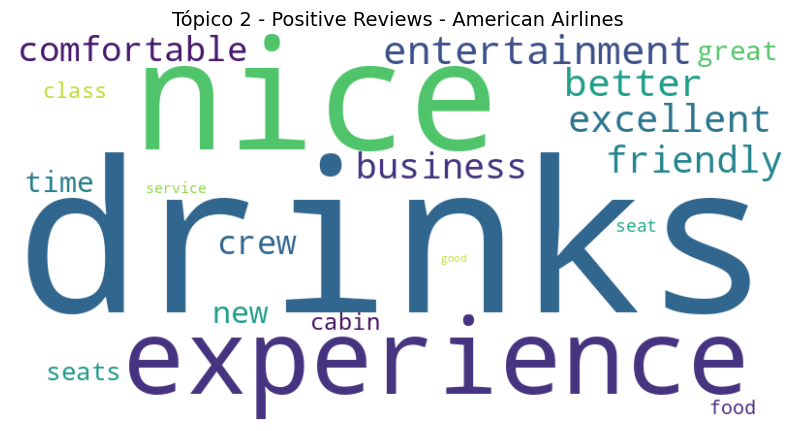

Generando nubes de palabras para negative reviews de Delta Air Lines...


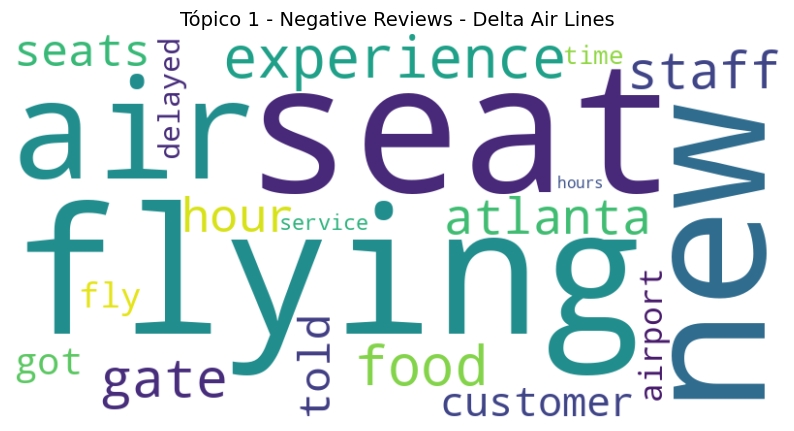

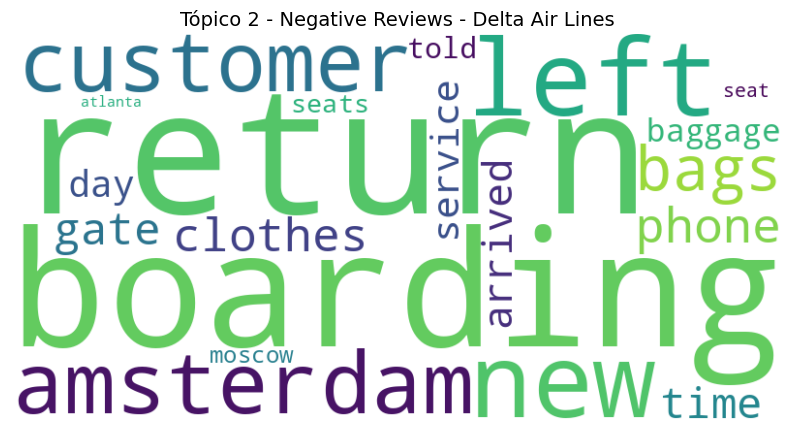

Generando nubes de palabras para positive reviews de Delta Air Lines...


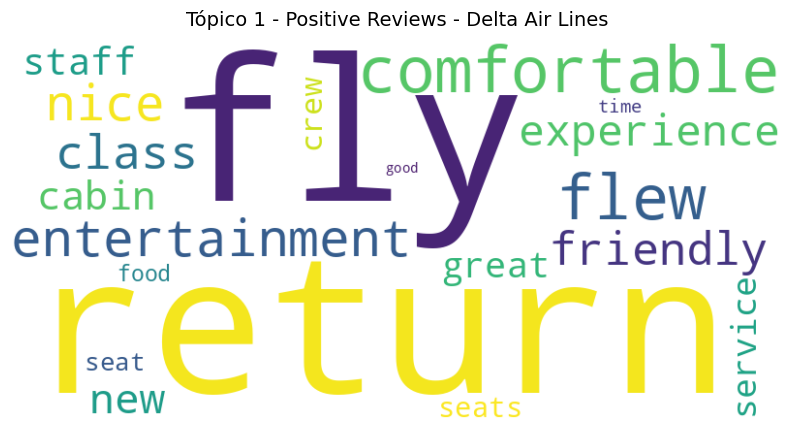

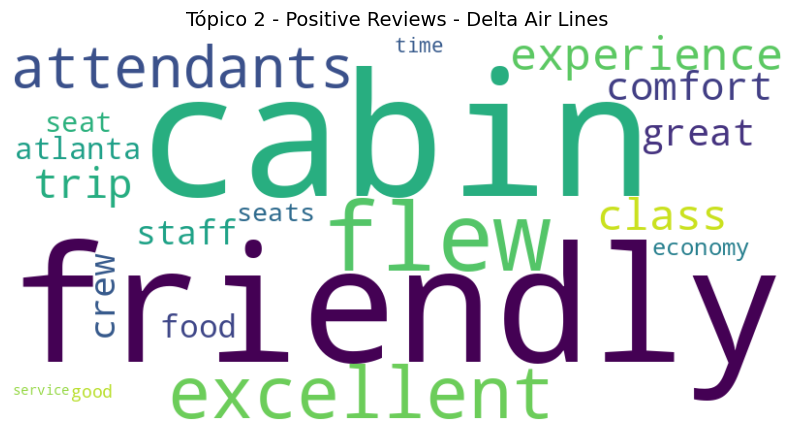

In [29]:
def generate_word_clouds_per_airline(topics, n_topics, airline, sentiment, title_prefix="Tópico"):
    if isinstance(topics, dict):  # Si topics es un diccionario
        topics = [words for _, words in topics.items()]

    for i in range(n_topics):
        if i >= len(topics):
            print(f"No hay suficiente información para generar nube de palabras para el tópico {i+1}")
            continue

        topic_words = topics[i]
        word_freq = {word: freq for freq, word in enumerate(topic_words, 1)}
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

        plt.figure(figsize=(10, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"{title_prefix} {i+1} - {sentiment.capitalize()} Reviews - {airline}", fontsize=14)
        plt.axis("off")
        plt.show()


# Generar nubes de palabras para cada aerolínea y sentimiento
for airline in airlines:
    for sentiment in sentiments:
        print(f"Generando nubes de palabras para {sentiment.lower()} reviews de {airline}...")

        df_filtered = df_sentiments[(df_sentiments['bert_sentiment'] == sentiment) & (df_sentiments['airline'] == airline)]

        if not df_filtered.empty:
            term_matrix, vectorizer = create_term_matrix(df_filtered['cleaned_review'])

            if term_matrix.shape[0] > 0:
                best_lda, n_topics = apply_lda(term_matrix, search_params)
                topics = display_topics(best_lda, vectorizer.get_feature_names_out(), 20)

                # Verificar la estructura de topics
                if isinstance(topics, list) or isinstance(topics, dict):
                    generate_word_clouds_per_airline(topics, n_topics, airline, sentiment, title_prefix="Tópico")
                else:
                    print("La estructura de tópicos no es compatible para generar nubes de palabras.")
            else:
                print(f"No hay suficientes datos para generar matriz de términos en {sentiment.lower()} reviews de {airline}.")
        else:
            print(f"No hay suficientes datos para análisis de tópicos en {sentiment.lower()} reviews de {airline}.")

### Conclusión

Se eligió el modelo de BERT debido a su mayor precisión para el análisis de texto y se complementó con un modelo LDA para identificar los tópicos más frecuentes en las reseñas.

En el caso de United Airlines, se identificaron dos tópicos principales. El primero está relacionado con retrasos, cancelaciones y un servicio al cliente deficiente. Ejemplos de comentarios reflejan frustración por esperas prolongadas, conexiones perdidas y la falta de apoyo por parte del personal: "El avión se retrasó por casi 3 horas, perdí mi conexión, y tuve que esperar 6 horas más para el próximo vuelo. Atención al cliente no fue útil en absoluto". El segundo tópico aborda la experiencia en cabina, destacando aspectos como asientos incómodos, comida insuficiente y la falta de entretenimiento: "Ocho horas de vuelo sin comidas gratis y sin pantallas de entretenimiento. El asiento era estrecho y el espacio limitado".

En cuanto a la competencia, se identificaron problemas similares. El primer tópico incluye comentarios sobre retrasos, cambios de puerta y cancelaciones, con especial énfasis en la desorganización y problemas con el equipaje: "Múltiples cambios de puerta y cancelaciones, con nula información clara. Mi equipaje terminó en otro destino". El segundo tópico se centra en la experiencia a bordo, incluyendo críticas sobre el servicio, la calidad de la comida y las distracciones innecesarias en el sistema de entretenimiento: "Las comidas eran mediocres y el sistema de entretenimiento estaba cargado de anuncios innecesarios".

Ambas aerolíneas comparten problemas comunes relacionados con retrasos, cancelaciones y la experiencia a bordo. Sin embargo, las críticas hacia United enfatizan una percepción más negativa respecto a su atención al cliente, lo que sugiere un área clave para mejorar y diferenciarse de la competencia.

In [30]:
!pip install bertopic hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5

In [31]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from bertopic import BERTopic

nltk.download('stopwords')

# Definir stopwords personalizadas
custom_stop_words = set(stopwords.words('english')).union({'flight', 'united', 'airline', 'plane', 'airlines', 'flights'})

# Función de preprocesamiento de texto
def preprocess_text(text, stopwords_set):
    text = text.lower()
    words = re.sub(r'\W+', ' ', text).split()
    words = [word for word in words if word not in stopwords_set]
    return ' '.join(words)

# Preprocesar texto
print("Preprocesando texto...")
df_sentiments['cleaned_review'] = df_sentiments['customer_review'].apply(lambda x: preprocess_text(str(x), custom_stop_words))

# Filtrar reseñas negativas de United Airlines
df_negative = df_sentiments[(df_sentiments['bert_sentiment'] == 'Negative') & (df_sentiments['airline'] == 'United Airlines')]

if not df_negative.empty:
    print("_" * 50)
    print("RESEÑAS NEGATIVAS DE UNITED AIRLINES")

    # Aplicar BERTopic
    topic_model_negative = BERTopic(min_topic_size=10, nr_topics="auto")
    topics_negative, _ = topic_model_negative.fit_transform(df_negative['cleaned_review'])

    # Obtener los temas en un formato más claro
    topics_info = topic_model_negative.get_topic_info()

    # Filtrar temas válidos y ordenarlos por cantidad de menciones
    topics_info = topics_info[topics_info['Topic'] != -1].sort_values(by='Count', ascending=False)

    print("\n**Temas principales en reseñas negativas de United Airlines:**")
    num_topics = min(5, len(topics_info))

    for i in range(num_topics):
        topic_id = topics_info.iloc[i]['Topic']
        words = topics_info.iloc[i]['Representation']
        count = topics_info.iloc[i]['Count']

        print(f" - **Tema {i+1} ({count} menciones):** {', '.join(words[:10])}")  # 10 palabras clave

        # Obtener una reseña representativa del tema
        top_review_idx = topics_negative.index(topic_id) if topic_id in topics_negative else None
        if top_review_idx is not None:
            print(f"   - Ejemplo de reseña: \"{df_negative.iloc[top_review_idx]['customer_review']}\"")
        print("-" * 50)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocesando texto...
__________________________________________________
RESEÑAS NEGATIVAS DE UNITED AIRLINES


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling%2Fconfig.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


**Temas principales en reseñas negativas de United Airlines:**
 - **Tema 1 (1771 menciones):** service, us, time, get, hours, would, one, never, told, fly
   - Ejemplo de reseña: " Newark to Miami. It was snowing all day in New Jersey, and I called to confirm whether my flight to MIA was delayed or cancelled and I was told it was not. I get to the airport and they delay my 8:50 pm flight about 6 times, to the point where it's 1 AM. They tell everyone the flight is cancelled because they cannot find a pilot. On top of randomly canceling the flight after the many delayed, they do not bother to accommodate us with a voucher for a taxi back home or a hotel. They just simply said to call the airline and book another flight. Not to mention how rude and unprofessional one of the ladies at the gate was. When I asked her for information on booking the next flight she gave me an attitude and didn't even answer my question. When I called their customer service phone number and spoke to a supervi

In [32]:
# Filtrar reseñas positivas de United Airlines
df_positive = df_sentiments[(df_sentiments['bert_sentiment'] == 'Positive') & (df_sentiments['airline'] == 'United Airlines')]

if not df_positive.empty:
    print("_" * 50)
    print("  RESEÑAS POSITIVAS DE UNITED AIRLINES")

    # Aplicar BERTopic
    topic_model_positive = BERTopic(min_topic_size=10, nr_topics="auto")
    topics_positive, _ = topic_model_positive.fit_transform(df_positive['cleaned_review'])

    # Obtener los temas en un formato más claro
    topics_info_positive = topic_model_positive.get_topic_info()

    # Filtrar temas válidos y ordenarlos por cantidad de menciones
    topics_info_positive = topics_info_positive[topics_info_positive['Topic'] != -1].sort_values(by='Count', ascending=False)

    print("\n- **Temas principales en reseñas positivas de United Airlines:**")
    num_topics_positive = min(5, len(topics_info_positive))

    for i in range(num_topics_positive):
        topic_id = topics_info_positive.iloc[i]['Topic']
        words = topics_info_positive.iloc[i]['Representation']
        count = topics_info_positive.iloc[i]['Count']

        print(f"- **Tema {i+1} ({count} menciones):** {', '.join(words[:10])}")  # 10 palabras clave

        # Obtener una reseña representativa del tema
        top_review_idx = topics_positive.index(topic_id) if topic_id in topics_positive else None
        if top_review_idx is not None:
            print(f"   - Ejemplo de reseña: \"{df_positive.iloc[top_review_idx]['customer_review']}\"")
        print("-" * 50)

__________________________________________________
  RESEÑAS POSITIVAS DE UNITED AIRLINES

- **Temas principales en reseñas positivas de United Airlines:**
- **Tema 1 (100 menciones):** francisco, class, san, service, entertainment, food, singapore, first, economy, flew
   - Ejemplo de reseña: " San Francisco to Hong Kong with United Airlines. Not an easy and quick check-in. Plane looked aged, nice leg room space, good inflight entertainment and very good Wi-Fi and internet connection at a reasonable price (for the entire flight), terrible blankets. Very nice and gentle cabin crew. Food wasnÂ´t poor quality and quantity for a flight of 14h30."
--------------------------------------------------
- **Tema 2 (91 menciones):** newark, first, time, crew, cabin, good, class, inflight, entertainment, hour
   - Ejemplo de reseña: " Mexico City to Newark. What happened to being treated with courtesy and a smile. I struggled to get to the airport for a 5:30 am flight and they eagerly switched to 

Los temas generados por BERTopic y LDA parecen ser similares en términos de los aspectos clave de la experiencia de vuelo, pero cada modelo los agrupa de manera distinta.

Coincidencias en los temas:

- Servicio: Ambos modelos abordan aspectos relacionados con el servicio, como la actitud de la tripulación, el confort, el servicio de alimentos, etc.

- Retrasos y tiempos: Los retrasos en los vuelos y los tiempos de espera también se mencionan en ambos modelos, aunque se agrupan de manera diferente.
- Equipaje: Los problemas con el equipaje o el manejo de maletas son otro tema común.

Diferencias en la agrupación:

- BERTopic tiende a agrupar temas de una forma más flexible, abarcando diferentes aspectos de una experiencia de vuelo en cada tema (por ejemplo, un tema sobre "tiempo" puede incluir tanto retrasos como duración de vuelos).
- LDA es más estructurado y puede identificar más detalles granulares, con diferentes temas para aspectos específicos (por ejemplo, un tema sobre "retrasos" y otro separado sobre "equipaje").
